# OWT Structural Model with PyDynSM: Part 4



Assumptions:
- dynamic SSI is neglected, so the soil response from question 3 will later act as the kinematic base excitation of the OWT
- the base of the OWT is rigidly connected to the ground surface
- the lower tower segment has length `H_w` and uses diameter set 1
- the upper tower segment has length `H_t - H_w` and uses diameter set 2
- the concentrated mass `M` and rotational inertia `J` are attached at the tower top


In [1]:
import io
from contextlib import redirect_stdout

import matplotlib.pyplot as plt
import numpy as np
import pydynsm as PDM
from scipy import optimize as opt
from scipy.signal import find_peaks

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


## 1. Problem Values


In [2]:
# Student-ID digits used throughout the assignment
A = 6
B = 6
C = 1
D = 1
E = 2
F = 5
G = 7

# Structural properties
M = (800 + 10 * F) * 1e3      # kg, 8F0 * 10^3
J = 300 * 1e6                 # kg m^2
rho_t = 7850.0                # kg/m^3
E_t = 210e9                   # Pa
xi_t = 0.001                  # -

D_out_1 = 9.1                 # m
D_inner_1 = 8.96              # m
D_out_2 = 7.1                 # m
D_inner_2 = 7.0               # m

F_w = 2e5                     # N
H_t = 140 + A                 # m
H_w = 30 + F                  # m

# Soil properties kept for consistency with the earlier notebooks
H_1 = 2 + B                   # m
H_2 = 58 + G                  # m
H_3 = 38 + F                  # m

G_1 = (100 + 10 * F) * 1e6    # Pa
rho_1 = 1650.0                # kg/m^3
eta_1 = (1000 + 10 * C)       # Ns/m^2

G_2 = (100 + 10 * D) * 1e6    # Pa
rho_2 = 1850.0                # kg/m^3
eta_2 = (1000 + 10 * E)       # Ns/m^2

G_3 = (100 + 10 * E) * 1e6    # Pa
rho_3 = 1900.0                # kg/m^3
eta_3 = (1000 + 10 * D)       # Ns/m^2

print("Student-ID digits:", {"A": A, "B": B, "C": C, "D": D, "E": E, "F": F, "G": G})
print(f"M = {M:,.0f} kg")
print(f"J = {J:,.0f} kg m^2")
print(f"H_t = {H_t:.1f} m")
print(f"H_w = {H_w:.1f} m")
print(f"Tower split: lower = {H_w:.1f} m, upper = {H_t - H_w:.1f} m")


Student-ID digits: {'A': 6, 'B': 6, 'C': 1, 'D': 1, 'E': 2, 'F': 5, 'G': 7}
M = 850,000 kg
J = 300,000,000 kg m^2
H_t = 146.0 m
H_w = 35.0 m
Tower split: lower = 35.0 m, upper = 111.0 m


In [3]:
def tube_section_properties(d_outer, d_inner):
    area = np.pi / 4.0 * (d_outer**2 - d_inner**2)
    inertia = np.pi / 64.0 * (d_outer**4 - d_inner**4)
    section_modulus = inertia / (d_outer / 2.0)
    return area, inertia, section_modulus


A_t1, I_t1, W_t1 = tube_section_properties(D_out_1, D_inner_1)
A_t2, I_t2, W_t2 = tube_section_properties(D_out_2, D_inner_2)

L_lower = float(H_w)
L_upper = float(H_t - H_w)

print("Lower segment properties:")
print(f"  A_1 = {A_t1:.6f} m^2")
print(f"  I_1 = {I_t1:.6f} m^4")
print(f"  W_1 = {W_t1:.6f} m^3")
print()
print("Upper segment properties:")
print(f"  A_2 = {A_t2:.6f} m^2")
print(f"  I_2 = {I_t2:.6f} m^4")
print(f"  W_2 = {W_t2:.6f} m^3")


Lower segment properties:
  A_1 = 1.985801 m^2
  I_1 = 20.241714 m^4
  W_1 = 4.448728 m^3

Upper segment properties:
  A_2 = 1.107411 m^2
  I_2 = 6.880486 m^4
  W_2 = 1.938165 m^3


## 2. OWT Beam Model

For the lateral in-plane response of the tower, the OWT is modeled with `EulerBernoulli Beam foundation attachments`.

Only the lateral translation and bending rotation are needed, so each node uses the DOFs

`['x', 'phi_y']`.

The nodal coordinates are:
- node 0: base at `z = 0`
- node 1: diameter change at `z = H_w`
- node 2: tower top at `z = H_t`

The base node is fixed for the free-vibration check. Later, in the forced-response part, the same base horizontal DOF can be prescribed to the ground-surface motion obtained from the soil model.


In [4]:
def build_owt_structure(ksi=xi_t):
    buffer = io.StringIO()
    with redirect_stdout(buffer):
        structure = PDM.Assembler("OWT beam model")

        nodes = [
            structure.CreateNode(0.0, 0.0, dof_config=["x", "phi_y"]),
            structure.CreateNode(0.0, L_lower, dof_config=["x", "phi_y"]),
            structure.CreateNode(0.0, H_t, dof_config=["x", "phi_y"]),
        ]

        elements = [
            structure.CreateElement([nodes[0], nodes[1]]),
            structure.CreateElement([nodes[1], nodes[2]]),
        ]

        elements[0].SetSection(
            "EulerBernoulli Beam foundation attachments",
            {
                "rho": rho_t,
                "A": A_t1,
                "E": E_t,
                "Ib": I_t1,
                "Wb": W_t1,
                "L": L_lower,
                "kd": 0.0,
                "cd": 0.0,
                "ksi": ksi,
            },
        )

        elements[1].SetSection(
            "EulerBernoulli Beam foundation attachments",
            {
                "rho": rho_t,
                "A": A_t2,
                "E": E_t,
                "Ib": I_t2,
                "Wb": W_t2,
                "L": L_upper,
                "kd": 0.0,
                "cd": 0.0,
                "Pm2": M,
                "J2": J,
                "ksi": ksi,
            },
        )

        nodes[0].fix_node("x", "phi_y")
        structure.run_connectivity()

    return structure, nodes, elements


def constrained_matrix(structure, omega):
    return structure.GlobalConstrainedStiffness(float(omega))


def smallest_singular_value(structure, omega):
    K_ff = constrained_matrix(structure, omega)
    return float(np.min(np.linalg.svd(K_ff, compute_uv=False)))


def find_natural_frequencies(
    structure,
    omega_min=0.01,
    omega_max=60.0,
    n_scan=5000,
    n_modes=4,
):
    omega_scan = np.linspace(omega_min, omega_max, n_scan)
    sigma_scan = np.array([smallest_singular_value(structure, omega) for omega in omega_scan])

    indicator = -np.log10(np.maximum(sigma_scan, 1e-30))
    peak_indices, _ = find_peaks(
        indicator,
        prominence=0.5,
        distance=max(50, n_scan // 100),
    )
    peak_indices = peak_indices[np.argsort(omega_scan[peak_indices])]

    omega_n = []
    for idx in peak_indices:
        left = omega_scan[max(idx - 15, 0)]
        right = omega_scan[min(idx + 15, n_scan - 1)]
        result = opt.minimize_scalar(
            lambda w: smallest_singular_value(structure, w),
            bounds=(left, right),
            method="bounded",
        )

        if omega_n and abs(result.x - omega_n[-1]) < 1e-3:
            continue

        omega_n.append(float(result.x))

        if len(omega_n) == n_modes:
            break

    return omega_scan, sigma_scan, np.array(omega_n)


def mode_vector(structure, omega):
    K_ff = constrained_matrix(structure, omega)
    _, _, vh = np.linalg.svd(K_ff)
    phi_free = vh[-1, :].astype(complex)

    reference_index = int(np.argmax(np.abs(phi_free)))
    phi_free = phi_free / phi_free[reference_index]

    if np.real(phi_free[-2]) < 0:
        phi_free = -phi_free

    return phi_free


def mode_profile(structure, omega, num_points_per_element=250):
    phi_free = mode_vector(structure, omega)
    u_full = structure.FullDisplacement(phi_free)
    element_displacements = structure.ElementDisplacements(
        u_full,
        omega,
        num_points=num_points_per_element,
        local_axes=True,
    )

    height_parts = []
    horizontal_parts = []

    for element in structure.elements:
        z_left = element.nodes[0].z
        z_right = element.nodes[1].z
        z_plot = np.linspace(z_left, z_right, num_points_per_element)
        x_plot = np.asarray(np.real_if_close(element_displacements[element.id][1]), dtype=complex)

        if height_parts:
            z_plot = z_plot[1:]
            x_plot = x_plot[1:]

        height_parts.append(z_plot)
        horizontal_parts.append(x_plot)

    height = np.concatenate(height_parts)
    horizontal = np.concatenate(horizontal_parts)

    max_abs = np.max(np.abs(horizontal))
    if max_abs > 0:
        horizontal = horizontal / max_abs

    if np.real(horizontal[-1]) < 0:
        horizontal = -horizontal

    return height, np.real_if_close(horizontal), u_full


## 3. Model Check and Natural Frequencies


Node coordinates [x, z] in m:
  node 0: [0.0, 0.0]
  node 1: [0.0, 35.0]
  node 2: [0.0, 146.0]

Free DOFs: [2 3 4 5]
Constrained DOFs: {0: 0, 1: 0}

First structural natural frequencies:
  mode 1: omega = 1.383447 rad/s,  f = 0.220183 Hz
  mode 2: omega = 9.015489 rad/s,  f = 1.434860 Hz
  mode 3: omega = 21.071031 rad/s,  f = 3.353559 Hz
  mode 4: omega = 43.259223 rad/s,  f = 6.884919 Hz


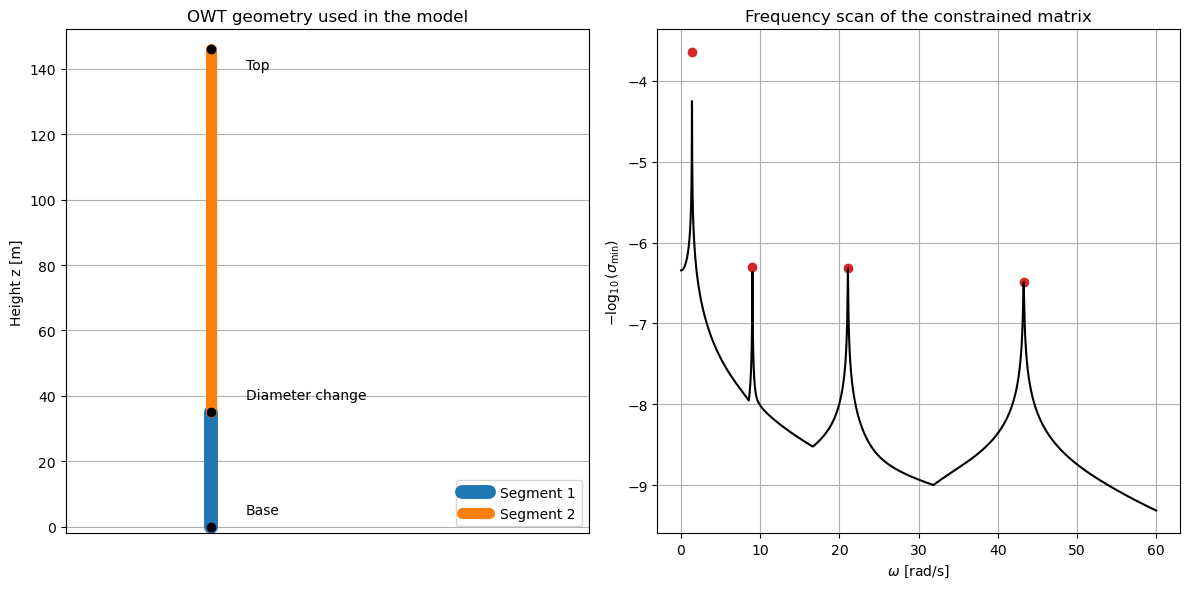

In [5]:
owt, owt_nodes, owt_elements = build_owt_structure()
omega_scan, sigma_scan, omega_n = find_natural_frequencies(owt)
f_n = omega_n / (2.0 * np.pi)

print("Node coordinates [x, z] in m:")
for i, node in enumerate(owt_nodes):
    print(f"  node {i}: [{node.x:.1f}, {node.z:.1f}]")

print()
print("Free DOFs:", owt.Analysis.free_dofs)
print("Constrained DOFs:", owt.Analysis.constrained_dofs)
print()
print("First structural natural frequencies:")
for i, (omega_i, freq_i) in enumerate(zip(omega_n, f_n), start=1):
    print(f"  mode {i}: omega = {omega_i:.6f} rad/s,  f = {freq_i:.6f} Hz")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot([0.0, 0.0], [0.0, L_lower], color="tab:blue", lw=10, solid_capstyle="round", label="Segment 1")
axes[0].plot([0.0, 0.0], [L_lower, H_t], color="tab:orange", lw=8, solid_capstyle="round", label="Segment 2")
axes[0].scatter([0.0, 0.0, 0.0], [0.0, L_lower, H_t], color="black", zorder=3)
axes[0].annotate("Base", (0.0, 0.0), xytext=(0.12, 4.0))
axes[0].annotate("Diameter change", (0.0, L_lower), xytext=(0.12, L_lower + 4.0))
axes[0].annotate("Top", (0.0, H_t), xytext=(0.12, H_t - 6.0))
axes[0].set_xlim(-0.5, 1.3)
axes[0].set_ylim(-2.0, H_t + 6.0)
axes[0].set_xticks([])
axes[0].set_ylabel("Height z [m]")
axes[0].set_title("OWT geometry used in the model")
axes[0].legend(loc="lower right")

indicator = -np.log10(np.maximum(sigma_scan, 1e-30))
axes[1].plot(omega_scan, indicator, color="black")
axes[1].scatter(omega_n, -np.log10(np.maximum([smallest_singular_value(owt, w) for w in omega_n], 1e-30)), color="tab:red")
axes[1].set_xlabel(r"$\omega$ [rad/s]")
axes[1].set_ylabel(r"$-\log_{10}(\sigma_{\min})$")
axes[1].set_title("Frequency scan of the constrained matrix")

plt.tight_layout()
plt.show()


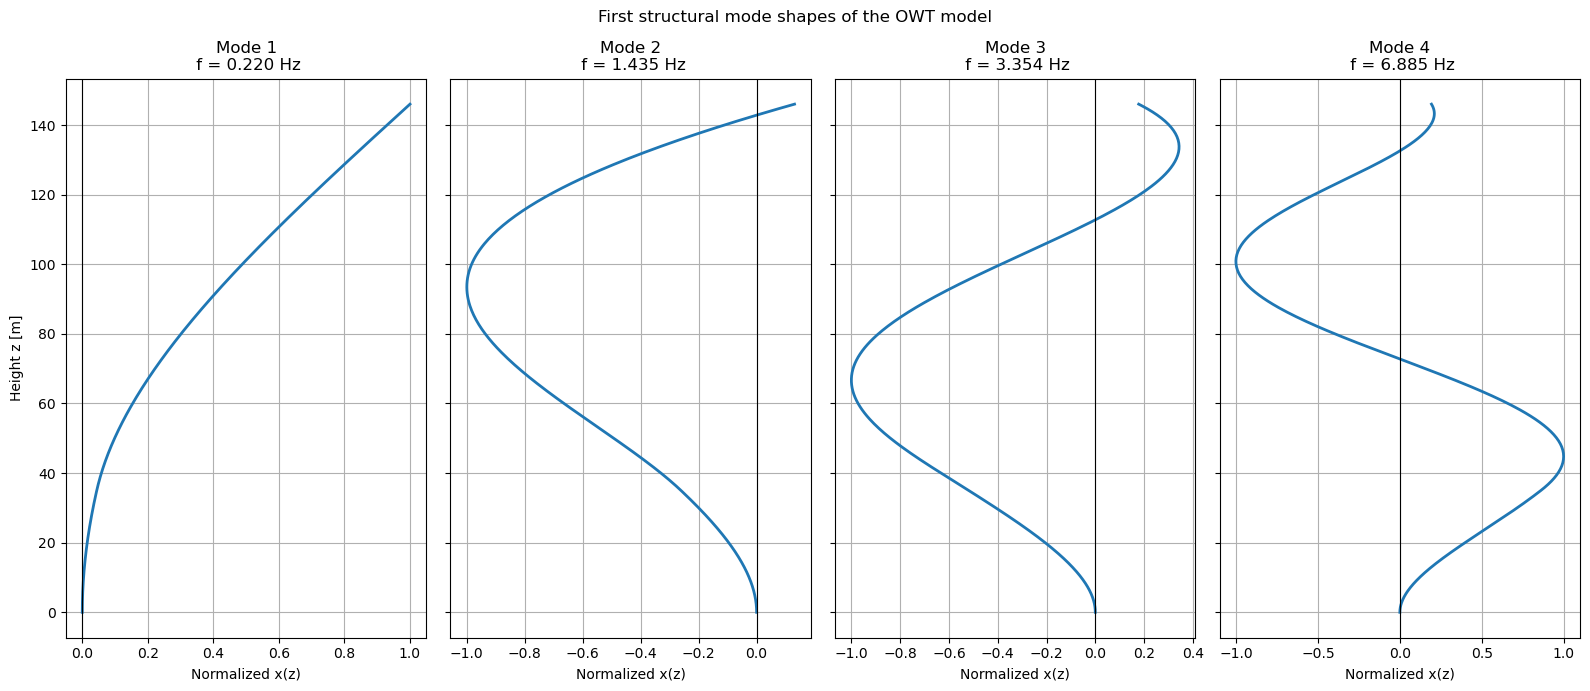

In [6]:
fig, axes = plt.subplots(1, len(omega_n), figsize=(4 * len(omega_n), 7), sharey=True)

for i, omega_i in enumerate(omega_n):
    height_i, horizontal_i, _ = mode_profile(owt, omega_i)
    axes[i].plot(np.real(horizontal_i), height_i, color="tab:blue", lw=2)
    axes[i].axvline(0.0, color="black", lw=0.8)
    axes[i].set_title(f"Mode {i + 1}\n f = {f_n[i]:.3f} Hz")
    axes[i].set_xlabel("Normalized x(z)")

axes[0].set_ylabel("Height z [m]")
fig.suptitle("First structural mode shapes of the OWT model")
fig.tight_layout()
plt.show()


## 4. Response Quantities for Later Parts

For this 3-node and 2-DOF-per-node model, `FullDisplacement` returns

`[base_x, base_phi_y, mid_x, mid_phi_y, top_x, top_phi_y]`.

The response quantities required later are:
- top displacement: horizontal displacement at the top node
- base bending moment: bending moment of element 0 at `s = 0`

For the seismic case, the base horizontal displacement will later be prescribed from the soil-surface motion obtained in question 3, while the base rotation remains zero.


In [7]:
def solve_base_excited_owt(structure, omega, U_base=1.0):
    omega = float(omega)
    K_global = structure.GlobalStiffness(omega)
    free = structure.Analysis.free_dofs
    constrained = np.array(list(structure.Analysis.constrained_dofs.keys()), dtype=int)

    # Prescribe horizontal base motion and keep the base rotation fixed.
    u_constrained = np.array([U_base, 0.0], dtype=complex)

    K_ff = K_global[np.ix_(free, free)]
    K_fc = K_global[np.ix_(free, constrained)]
    u_free = np.linalg.solve(K_ff, -(K_fc @ u_constrained))

    return structure.FullDisplacement(u_free)


def owt_response_quantities(structure, u_full, omega):
    element_forces = structure.ElementForces(u_full, float(omega), num_points=2)
    return {
        "top_displacement": u_full[4],
        "base_shear": element_forces[0][1][0],
        "base_bending_moment": element_forces[0][5][0],
    }


omega_demo = 1.0
u_demo = solve_base_excited_owt(owt, omega_demo, U_base=1.0)
response_demo = owt_response_quantities(owt, u_demo, omega_demo)

print(f"Demo response at omega = {omega_demo:.1f} rad/s for U_base = 1.0 m:")
for key, value in response_demo.items():
    print(f"  {key}: {value}")


Demo response at omega = 1.0 rad/s for U_base = 1.0 m:
  top_displacement: (2.2106233991723-0.0050727848806018765j)
  base_shear: (-1193430473.4903986-2372928.4352296973j)
  base_bending_moment: (21252094868.256325+40752322.25515209j)
